# Подготовка к самостоятельной работе: ключевые методы для проекта по предиктивной аналитике

## Учебный ноутбук-практикум

Этот ноутбук **не содержит готовых решений** для практических заданий из основного учебного пособия. Вместо этого он систематически объясняет **методы и техники**, которые потребуются для самостоятельного выполнения всех пяти заданий.

Все примеры строятся на **синтетических или общедоступных учебных датасетах** (Iris, make_classification, make_blobs), чтобы методы были усвоены в чистом виде, а затем студент мог применить их к данным реальной ветроэнергетической установки.

### Соответствие разделов и заданий

| Раздел ноутбука | Задание из основного пособия |
|---|---|
| 1. Визуализация распределений признака по группам | Задание 1 (boxplot реактивной мощности по типам отказов) |
| 2. Семейство методов балансировки классов | Задание 2 (замена SMOTE на BorderlineSMOTE) |
| 3. Интерпретация моделей: важность признаков | Задание 3 (feature importance тюнингованной модели) |
| 4. Валидация временных рядов | Задание 4 (замена StratifiedKFold на TimeSeriesSplit) |
| 5. Снижение размерности и визуализация | Задание 5 (PCA-проекция признаков SCADA) |

### Как работать с этим ноутбуком

1. Каждый раздел содержит **теоретическое введение со ссылками** на первоисточники и документацию;
2. Все методы демонстрируются на **простых учебных примерах**, где результат можно проинтерпретировать без специальных знаний предметной области;
3. В конце каждого раздела — **наводящие вопросы**, которые помогают перенести знание на ваш проект;
4. **Решения заданий не приведены** — это самостоятельная работа.

### Подключение библиотек


In [1]:
# Установка дополнительных пакетов
!pip install -q imbalanced-learn umap-learn

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Учебные датасеты sklearn
from sklearn.datasets import (load_iris, make_classification,
                                make_blobs, make_moons)

# Препроцессинг и метрики
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                       TimeSeriesSplit, cross_val_score)
from sklearn.metrics import classification_report, f1_score

# Модели
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 5)
np.random.seed(42)

print('Окружение готово.')

Окружение готово.


## 1. Визуализация распределений признака по группам

**Соответствует заданию 1.** В вашем основном проекте вам нужно построить boxplot для одного физического канала по разным категориям отказов и **проинтерпретировать**, что вы видите.

### Теоретическая основа

Цель сравнения распределений по группам — ответить на вопрос: **различает ли данный признак классы?** Если медианы и квартили распределений сильно различаются между группами — признак информативен; если распределения перекрываются — нет.

Для этой задачи есть несколько графических средств с разной информативностью:

| Метод | Что показывает | Когда выбирать |
|---|---|---|
| **Boxplot** | Медиана, Q1, Q3, выбросы (по 1.5 IQR) | Стандартное сравнение, не более 10 групп |
| **Violin plot** | Полная плотность распределения (KDE) | Когда важна форма (мультимодальность, асимметрия) |
| **Strip plot** | Каждый объект отдельной точкой | Малая выборка (< 200), показать все наблюдения |
| **Swarm plot** | Strip с разрешением перекрытий | Средняя выборка (200–2000) |
| **Boxen plot** | Boxplot с детализацией хвостов | Очень большие выборки, тяжёлые хвосты |

Документация: [`seaborn.boxplot`](https://seaborn.pydata.org/generated/seaborn.boxplot.html), [`seaborn.violinplot`](https://seaborn.pydata.org/generated/seaborn.violinplot.html), [`seaborn.stripplot`](https://seaborn.pydata.org/generated/seaborn.stripplot.html), [`seaborn.boxenplot`](https://seaborn.pydata.org/generated/seaborn.boxenplot.html).

### Анатомия boxplot

Прямоугольник («ящик») — межквартильный размах от $Q_1$ (25-й перцентиль) до $Q_3$ (75-й). Горизонтальная линия внутри — медиана ($Q_2$). «Усы» простираются до самого дальнего наблюдения, попадающего в $[Q_1 - 1{,}5 \cdot \mathrm{IQR}, \; Q_3 + 1{,}5 \cdot \mathrm{IQR}]$, где $\mathrm{IQR} = Q_3 - Q_1$. Точки за пределами усов — потенциальные **выбросы** по правилу Тьюки.

Первоисточник правила: [Tukey J. W., *Exploratory Data Analysis*, Addison-Wesley, 1977](https://archive.org/details/exploratorydataa00tuke_0).


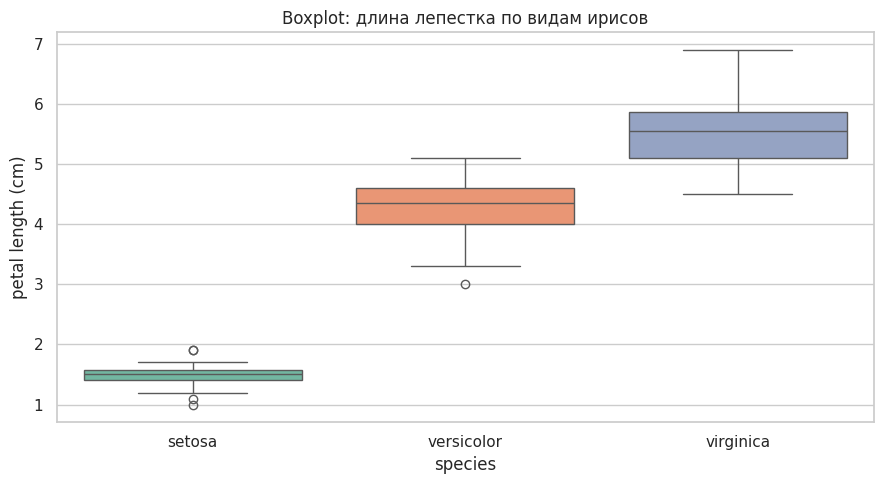

In [3]:
# Учебный датасет: ирисы Фишера. Хорошо подходит для демонстрации разделимости.
iris = load_iris(as_frame=True)
df_iris = iris.frame.copy()
df_iris['species'] = df_iris['target'].map(dict(enumerate(iris.target_names)))

# Стандартный boxplot
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df_iris, x='species', y='petal length (cm)',
            palette='Set2', ax=ax)
ax.set_title('Boxplot: длина лепестка по видам ирисов')
plt.tight_layout()
plt.show()

**Чтение графика.** Виды `setosa`, `versicolor`, `virginica` имеют **полностью непересекающиеся «ящики»** по длине лепестка. Это означает, что одного этого признака почти достаточно для разделения трёх классов. В реальных физических задачах такая идеальная разделимость встречается редко.

### Сравнение четырёх визуализаций на одних данных

Покажем, как один и тот же набор данных выглядит при разных способах визуализации.


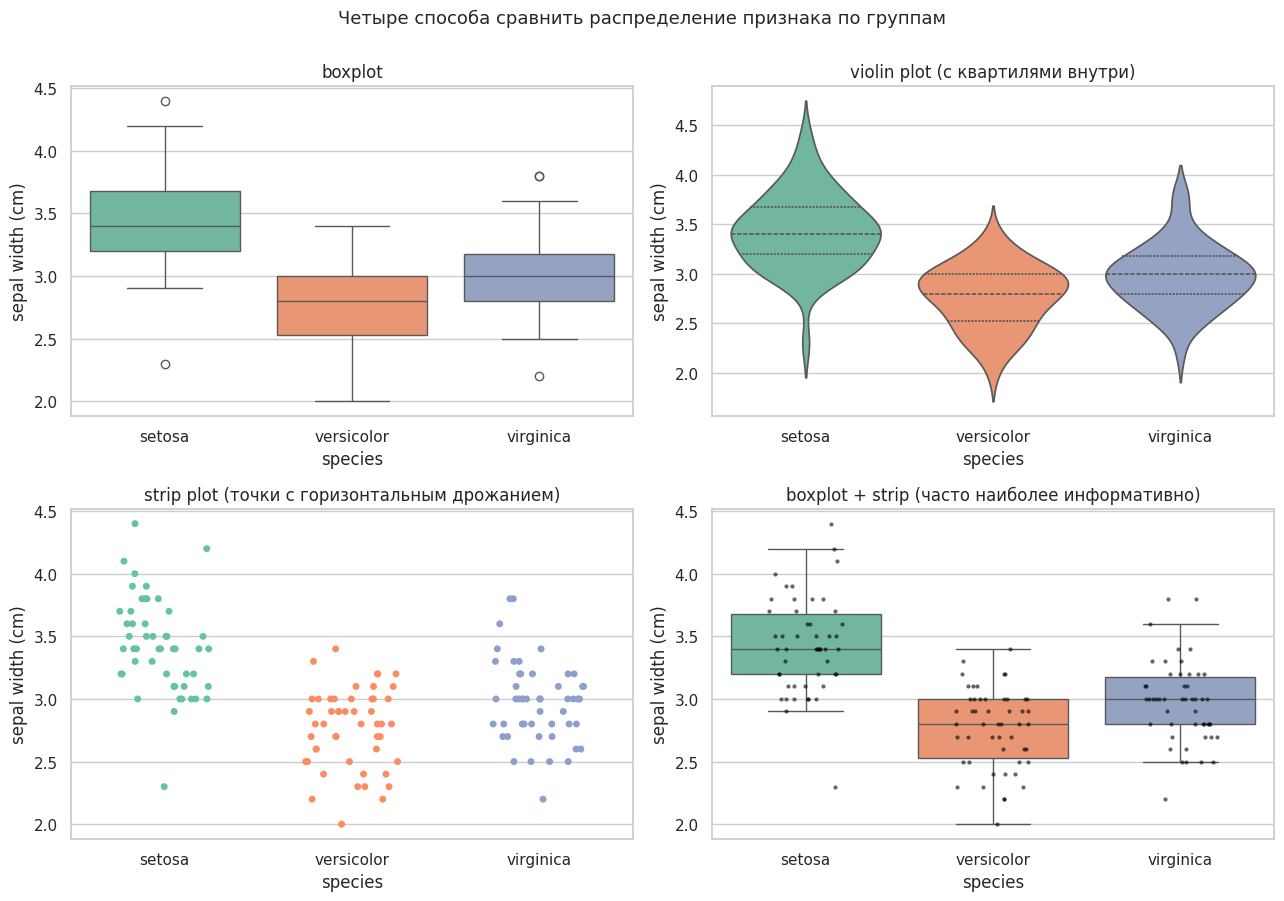

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.boxplot(data=df_iris, x='species', y='sepal width (cm)',
            palette='Set2', ax=axes[0, 0])
axes[0, 0].set_title('boxplot')

sns.violinplot(data=df_iris, x='species', y='sepal width (cm)',
                palette='Set2', inner='quartile', ax=axes[0, 1])
axes[0, 1].set_title('violin plot (с квартилями внутри)')

sns.stripplot(data=df_iris, x='species', y='sepal width (cm)',
                palette='Set2', size=5, jitter=0.25, ax=axes[1, 0])
axes[1, 0].set_title('strip plot (точки с горизонтальным дрожанием)')

# Комбинация: boxplot + поверх него точки
sns.boxplot(data=df_iris, x='species', y='sepal width (cm)',
            palette='Set2', ax=axes[1, 1], showfliers=False)
sns.stripplot(data=df_iris, x='species', y='sepal width (cm)',
                color='black', size=3, jitter=0.2, alpha=0.6, ax=axes[1, 1])
axes[1, 1].set_title('boxplot + strip (часто наиболее информативно)')

plt.suptitle('Четыре способа сравнить распределение признака по группам',
             fontsize=13, y=1.00)
plt.tight_layout()
plt.show()

**На что обращать внимание при интерпретации графика.**

1. **Положение медианы.** Если медианы групп явно различаются — признак разделяет классы.
2. **Перекрытие «ящиков».** Перекрывающиеся межквартильные размахи означают, что многие объекты разных классов имеют схожие значения признака — разделение неполное.
3. **Ширина «ящика».** Узкий ящик — признак внутри класса принимает мало различающиеся значения (низкая дисперсия). Широкий — высокая внутриклассовая вариация.
4. **Выбросы.** Точки за усами могут быть как ошибками измерения, так и редкими, но физически валидными режимами. Не удалять их автоматически — сначала разобраться в причине.
5. **Асимметрия.** Если медиана смещена к одному краю ящика, а усы разной длины — распределение скошено. Это видно на violin plot, но не на boxplot.

### Особенности больших и несбалансированных выборок

Когда классы имеют очень разный размер (например, 10 000 «нормальных» против 30 «отказа»), стандартный boxplot для крупного класса будет «съедать» внимание. Применяют два приёма:

1. **Подвыборка мажоритарного класса** до сопоставимого размера — для визуализации (не для обучения!);
2. **Использование `boxenplot`** — он лучше передаёт детали распределения в хвостах.


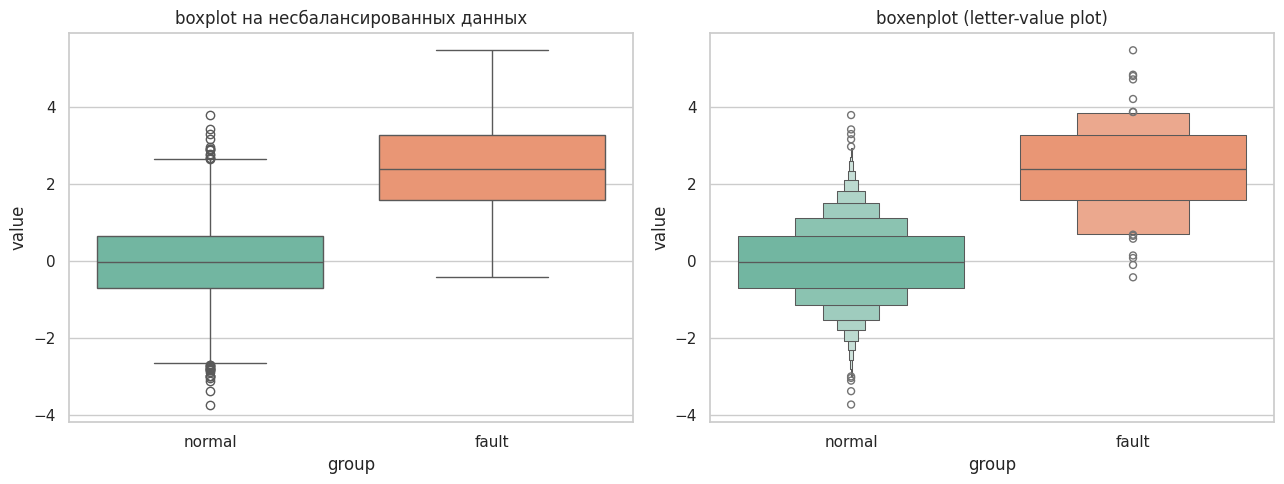

Медианы по группам:
          median       std  count
group                            
fault   2.404684  1.365567     50
normal -0.021891  0.985435   5000


In [5]:
# Создадим искусственно несбалансированный пример
np.random.seed(0)
n_big, n_small = 5000, 50
df_imbalanced = pd.DataFrame({
    'value': np.concatenate([
        np.random.normal(0,    1.0, n_big),
        np.random.normal(2.5,  1.2, n_small),
    ]),
    'group': ['normal'] * n_big + ['fault'] * n_small
})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Слева: стандартный boxplot — почти не видно класса 'fault'
sns.boxplot(data=df_imbalanced, x='group', y='value',
            palette='Set2', ax=axes[0])
axes[0].set_title('boxplot на несбалансированных данных')

# Справа: boxenplot — лучше виден малый класс
sns.boxenplot(data=df_imbalanced, x='group', y='value',
                palette='Set2', ax=axes[1])
axes[1].set_title('boxenplot (letter-value plot)')

plt.tight_layout()
plt.show()

# Проверим, насколько отличаются медианы
print('Медианы по группам:')
print(df_imbalanced.groupby('group')['value'].agg(['median', 'std', 'count']))

### Как применить к вашему проекту (задание 1)

Не привожу готовый код — это часть задания. Но даю **наводящие вопросы**:

1. **Какой канал вы анализируете?** В задании указан конкретный канал. Какова его физическая природа (мощность, температура, угол, скорость)? Какие единицы измерения?
2. **Какова физическая логика отказа `EF`** (excitation fault, отказ возбуждения генератора)? Что **должно** происходить с реактивной мощностью при таком отказе с инженерной точки зрения — она должна расти, падать или становиться нестабильной? Сначала **сформулируйте гипотезу**, а потом проверяйте её графически.
3. **Какой порядок классов выбрать на оси X?** Полезно сравнивать с «нормальным» классом — он должен быть, например, слева, а классы отказа — справа.
4. **Что считать «характерной чертой» класса `EF`?** Если медиана `EF` сильно отличается от медианы `NF` — это маркер. Если межквартильный размах `EF` сильно шире — это указывает на нестабильность режима, что **тоже диагностически ценно**.
5. **Стоит ли посмотреть на тот же канал в логарифмической или абсолютных значениях?** Если данные могут быть отрицательными (как реактивная мощность), боксплот в абсолютных значениях иногда даёт более чёткую картину.

В ответе на задание ожидается не просто график, а **2–3 предложения с физической интерпретацией** того, что видно.


## 2. Семейство методов балансировки классов

**Соответствует заданию 2.** В основном проекте вам нужно заменить `SMOTE` на `BorderlineSMOTE` в pipeline и сравнить результаты. Этот раздел даёт теорию всех основных методов балансировки.

### Зачем нужна балансировка

Стандартные классификаторы обучаются на минимизации **средней** ошибки по обучающей выборке. Если класс A составляет 95 % данных, а класс B — 5 %, то модель, которая всегда предсказывает A, имеет accuracy = 95 % — но абсолютно бесполезна для задачи детектирования редких событий.

Решение — изменить распределение классов в обучающей выборке (sampling) или взвесить ошибки (cost-sensitive learning). Существуют три семейства методов:

| Семейство | Идея | Когда применять |
|---|---|---|
| **Oversampling** | Увеличить миноритарный класс (копии, синтетические объекты) | Когда данных мало в целом |
| **Undersampling** | Уменьшить мажоритарный класс | Когда данных много, можно «отдать» часть |
| **Combined** | Комбинация двух подходов | Сильный дисбаланс + много шума |

Полный обзор: [Lemaître et al., *Imbalanced-learn*, JMLR 2017](https://jmlr.org/papers/v18/16-365.html); документация: [imbalanced-learn.org](https://imbalanced-learn.org/stable/).

### Алгоритмы oversampling: четыре варианта

#### 2.1. Random Over-Sampler
Простейший метод: случайным образом дублирует объекты миноритарного класса до достижения баланса. **Проблема:** точные копии не несут новой информации, модель может переобучиться на конкретные примеры.

[`imblearn.over_sampling.RandomOverSampler`](https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.RandomOverSampler.html)

#### 2.2. SMOTE (Synthetic Minority Over-sampling Technique)
Для каждого объекта миноритарного класса находит $k$ ближайших соседей **того же класса**, выбирает одного случайно, и генерирует новый синтетический объект **на отрезке** между ними:
$$ x_{new} = x_i + \lambda (x_{nn} - x_i), \quad \lambda \sim U(0, 1) $$

Первоисточник: [Chawla et al., *SMOTE*, JAIR 2002](https://www.jair.org/index.php/jair/article/view/10302).

**Преимущество:** новые объекты лежат в области миноритарного класса, но не совпадают с существующими.
**Недостаток:** SMOTE не учитывает, что некоторые миноритарные объекты находятся **глубоко внутри** области мажоритарного класса (зашумлённые), и для них синтез приводит к ещё большему перекрытию классов.

#### 2.3. BorderlineSMOTE
Модификация SMOTE: синтетические объекты создаются **только для тех миноритарных точек, которые находятся на границе с мажоритарным классом**. Точки в безопасных областях («чисто миноритарных») и в шумных областях («окружённых мажоритарными») не используются.

Первоисточник: [Han et al., *Borderline-SMOTE*, ICIC 2005](https://link.springer.com/chapter/10.1007/11538059_91).

**Преимущество:** концентрируется на области, где модели тяжелее всего — там, где классы соприкасаются.
**Недостаток:** при очень малом миноритарном классе пограничных точек может оказаться мало.

#### 2.4. ADASYN (Adaptive Synthetic Sampling)
Похож на BorderlineSMOTE, но генерирует **больше** синтетических объектов для тех миноритарных точек, рядом с которыми больше соседей из мажоритарного класса. То есть «трудные» миноритарные объекты получают больше синтетических соседей.

Первоисточник: [He et al., *ADASYN*, IJCNN 2008](https://ieeexplore.ieee.org/document/4633969).

Все эти методы вызываются единообразно через `imbalanced-learn`. Покажем визуально, чем они различаются на двумерном примере.


До балансировки: класс 0 = 930, класс 1 = 70


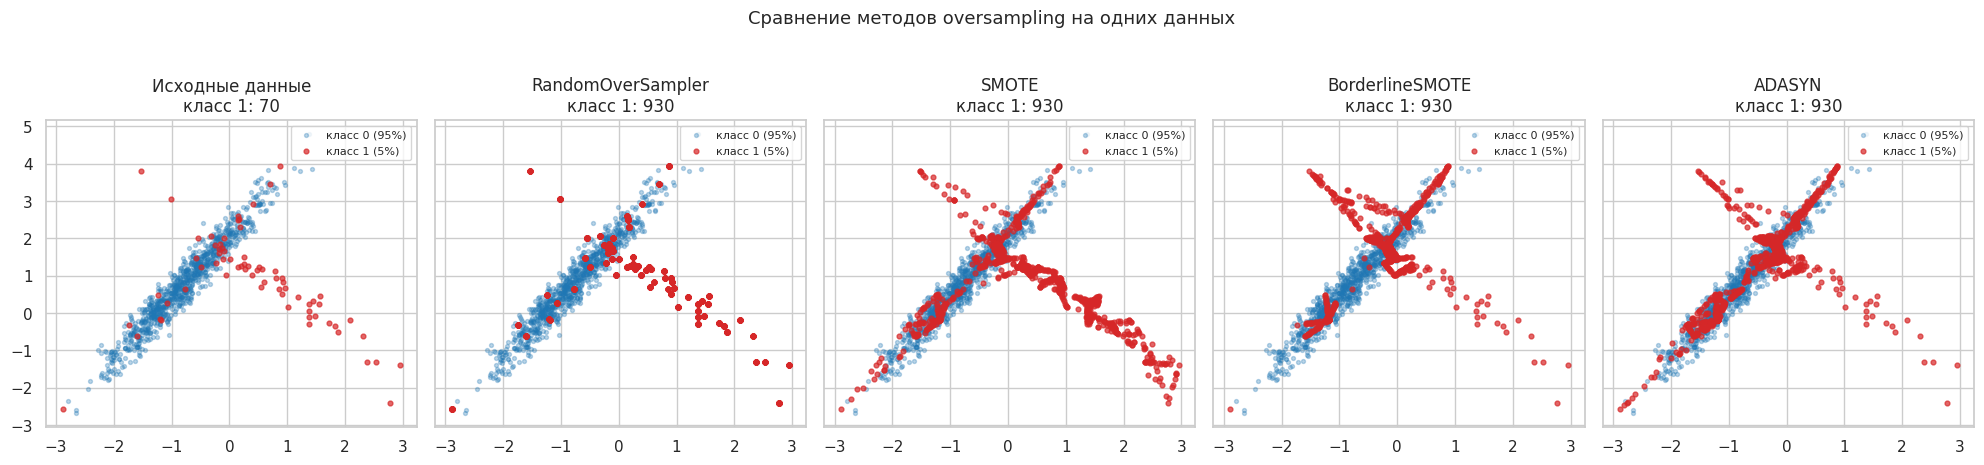

In [6]:
from imblearn.over_sampling import (SMOTE, BorderlineSMOTE,
                                       ADASYN, RandomOverSampler)

# Создадим двумерный несбалансированный датасет
X, y = make_classification(n_samples=1000, n_features=2, n_informative=2,
                             n_redundant=0, n_clusters_per_class=1,
                             weights=[0.95, 0.05], flip_y=0.05,
                             class_sep=0.8, random_state=42)
print(f'До балансировки: класс 0 = {np.sum(y==0)}, класс 1 = {np.sum(y==1)}')

samplers = {
    'Исходные данные': None,
    'RandomOverSampler': RandomOverSampler(random_state=42),
    'SMOTE':              SMOTE(random_state=42, k_neighbors=5),
    'BorderlineSMOTE':    BorderlineSMOTE(random_state=42, k_neighbors=5),
    'ADASYN':             ADASYN(random_state=42, n_neighbors=5),
}

fig, axes = plt.subplots(1, 5, figsize=(20, 4.5), sharex=True, sharey=True)

for ax, (name, sampler) in zip(axes, samplers.items()):
    if sampler is None:
        X_show, y_show = X, y
    else:
        X_show, y_show = sampler.fit_resample(X, y)
    ax.scatter(X_show[y_show == 0, 0], X_show[y_show == 0, 1],
                s=8, alpha=0.3, color='#1f77b4', label='класс 0 (95%)')
    ax.scatter(X_show[y_show == 1, 0], X_show[y_show == 1, 1],
                s=12, alpha=0.7, color='#d62728', label='класс 1 (5%)')
    n1 = (y_show == 1).sum()
    ax.set_title(f'{name}\nкласс 1: {n1}')
    ax.legend(loc='upper right', fontsize=8)

plt.suptitle('Сравнение методов oversampling на одних данных',
             fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

### Что видно на сравнении

1. **RandomOverSampler** просто дублирует существующие точки — на графике это видно как «жирные» области в исходных позициях.
2. **SMOTE** создаёт новые точки **по всей области** миноритарного класса, в том числе там, где он не пересекается с большинством. Это работает хорошо, если миноритарные точки занимают компактную область.
3. **BorderlineSMOTE** концентрируется на **границе** классов. Новые точки появляются преимущественно там, где исходные миноритарные точки граничат с мажоритарными. В безопасных областях новых точек почти нет.
4. **ADASYN** похож на BorderlineSMOTE, но плотность синтетических точек распределена адаптивно — больше там, где «трудно».

### Когда какой метод выбирать

| Ситуация | Рекомендация |
|---|---|
| Чистые классы, миноритарный компактен | SMOTE (стандартный) |
| Классы сильно перекрываются | BorderlineSMOTE или ADASYN |
| Очень малый миноритарный класс (< 50 объектов) | SMOTE с `k_neighbors=3` или Random + Tomek |
| Шумные данные | SMOTE + Tomek (комбинированный метод) |
| Хочется простоту и интерпретируемость | RandomOverSampler |

### Подводный камень: SMOTE и кросс-валидация

Самая частая ошибка — применять SMOTE **до** разбиения на train/test:

```python
# НЕПРАВИЛЬНО: синтетические объекты могут попасть в test
X_resampled, y_resampled = SMOTE().fit_resample(X, y)
X_tr, X_te, y_tr, y_te = train_test_split(X_resampled, y_resampled)
```

Правильный путь — поместить SMOTE **внутрь pipeline**, тогда он применяется только к обучающей части каждого фолда кросс-валидации:

```python
# ПРАВИЛЬНО: используем imblearn.pipeline (не sklearn.pipeline!)
from imblearn.pipeline import make_pipeline
pipe = make_pipeline(SMOTE(random_state=42), classifier)
cross_val_score(pipe, X, y, cv=StratifiedKFold(n_splits=5))
```

Подробное объяснение этого подхода: [Common pitfalls in imbalanced-learn](https://imbalanced-learn.org/stable/common_pitfalls.html).

### Метрика для оценки эффекта балансировки

Сравнение методов по `accuracy` бессмысленно (она почти не меняется). Правильные метрики:
- **macro F1** — среднее F1 по классам без учёта размера;
- **Average Precision (PR-AUC)** — площадь под precision-recall кривой, чувствительна к миноритарному классу;
- **G-mean** — среднее геометрическое recall по классам, штрафует за провал любого класса.


In [7]:
# Учебный пример: сравним macro F1 четырёх балансировщиков
from imblearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

results = {}
for name, sampler in samplers.items():
    if sampler is None:
        # Базовая линия: без балансировки
        pipe = RandomForestClassifier(n_estimators=50, random_state=42)
    else:
        pipe = make_pipeline(sampler,
                              RandomForestClassifier(n_estimators=50, random_state=42))
    scores = cross_val_score(pipe, X_train, y_train,
                              cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                              scoring='f1_macro')
    results[name] = scores.mean()

pd.Series(results, name='macro F1').to_frame().round(3)

,macro F1
Исходные данные,0.866
RandomOverSampler,0.832
SMOTE,0.741
BorderlineSMOTE,0.749
ADASYN,0.626


### Как применить к вашему проекту (задание 2)

Решение не привожу — это часть задания. Подумайте над следующим:

1. **Какой параметр `k_neighbors` использовать?** BorderlineSMOTE имеет параметр `k_neighbors` (для генерации) и `m_neighbors` (для определения «границы»). При малом классе их нужно уменьшать. В вашем проекте класс `MF` имеет всего ≈9 объектов в train — какие значения `k_neighbors` и `m_neighbors` физически возможны?
2. **Какую метрику использовать для сравнения?** Просто accuracy не подойдёт. Используйте per-class F1, чтобы увидеть, на каких классах прирост, а на каких — провал. Возможно, BorderlineSMOTE улучшит один класс, но ухудшит другой — это **операционно значимо** и заслуживает обсуждения.
3. **Достаточно ли одного запуска?** Эффект балансировки имеет случайную составляющую. Запустите 3–5 раз с разным `random_state` и посмотрите, стабильно ли BorderlineSMOTE лучше SMOTE на ваших данных, или это случайный выигрыш.
4. **Что физически означает «граница» в вашей задаче?** Где BorderlineSMOTE «концентрирует» синтез — это область пересечения каких физических режимов?
5. **Стоит ли попробовать ADASYN тоже?** Если есть время — попробуйте, это даст более полную картину.


## 3. Интерпретация моделей: важность признаков

**Соответствует заданию 3.** В основном проекте вам нужно извлечь важности признаков из тюнингованной модели LightGBM и проинтерпретировать топ-5. Этот раздел разбирает, что такое «важность признака», какие методы её измеряют, и как избежать типичных ошибок интерпретации.

### Что такое важность признака

Интуитивно — это мера того, **насколько данный признак помогает модели делать предсказания**. Формализаций несколько, и они **дают разные ответы**.

| Метод | Что измеряет | Достоинства | Недостатки |
|---|---|---|---|
| **Mean Decrease in Impurity (MDI)** | Суммарное снижение примеси (gini/entropy) во всех узлах, использующих признак | Быстро, доступно сразу после обучения | Завышает важность признаков с большим числом уникальных значений и непрерывных |
| **Split count** | Сколько раз признак использовался для разбиения | Простая интерпретация | Не учитывает, насколько хорошее это было разбиение |
| **Permutation importance** | Падение качества модели при случайной перестановке значений признака | Независим от модели, не зависит от структуры | Медленный, может давать нулевую важность при сильной корреляции признаков |
| **SHAP-значения** | Вклад признака в конкретное предсказание (теория Шепли) | Локальная интерпретация, теоретически обоснован | Самый медленный, требует отдельной библиотеки |

Ключевая работа по permutation importance: [Breiman, *Random Forests*, Machine Learning, 2001](https://link.springer.com/article/10.1023/A:1010933404324).
Ключевая работа по SHAP: [Lundberg & Lee, *A Unified Approach to Interpreting Model Predictions*, NeurIPS 2017](https://papers.nips.cc/paper/7062-a-unified-approach-to-interpreting-model-predictions).

### MDI: что в действительности возвращает `.feature_importances_`

У всех древесных моделей sklearn (Decision Tree, Random Forest, Gradient Boosting) после обучения доступен атрибут `.feature_importances_`. По умолчанию это **MDI**: суммарное снижение примеси (gini для классификации, MSE для регрессии) при разбиениях, использующих данный признак, усреднённое по деревьям.

Важно понимать **математический смысл**: чем сильнее уменьшилась «нечистота» узла после разбиения по признаку — тем больше вклад этого признака в общую важность.


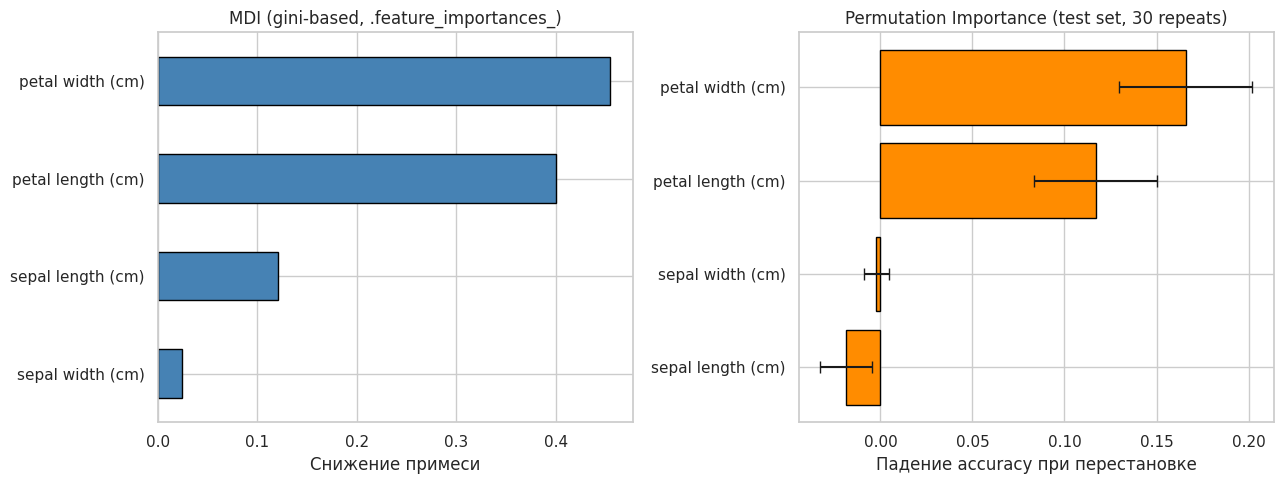

Топ-2 признака по MDI:         ['petal width (cm)', 'petal length (cm)']
Топ-2 признака по Permutation: ['petal width (cm)', 'petal length (cm)']


In [8]:
# Учебный пример: предсказание вида ириса
from sklearn.inspection import permutation_importance

# Превращаем DataFrame в numpy-массив для удобства индексирования
X = iris.data.values
y = iris.target.values
feature_names = list(iris.feature_names)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 1) Mean Decrease in Impurity (MDI)
mdi = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=True)

# 2) Permutation importance — независимый от структуры модели метод
perm = permutation_importance(rf, X_test, y_test, n_repeats=30, random_state=42)
perm_series = pd.Series(perm.importances_mean, index=feature_names).sort_values(ascending=True)
perm_std    = pd.Series(perm.importances_std,  index=feature_names)

# Визуализация двух методов рядом
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

mdi.plot(kind='barh', color='steelblue', edgecolor='black', ax=axes[0])
axes[0].set_title('MDI (gini-based, .feature_importances_)')
axes[0].set_xlabel('Снижение примеси')

axes[1].barh(perm_series.index, perm_series.values,
              xerr=perm_std.loc[perm_series.index].values,
              color='darkorange', edgecolor='black', capsize=4)
axes[1].set_title('Permutation Importance (test set, 30 repeats)')
axes[1].set_xlabel('Падение accuracy при перестановке')

plt.tight_layout()
plt.show()

print('Топ-2 признака по MDI:        ', list(mdi.sort_values(ascending=False).head(2).index))
print('Топ-2 признака по Permutation:', list(perm_series.sort_values(ascending=False).head(2).index))

**Что заметно.** На ирисах оба метода обычно согласуются — топ-2 одни и те же (длина и ширина лепестка). Но **в реальных задачах с коррелированными признаками** ответы могут заметно различаться. Рассмотрим это явление специально.

### Проблема коррелированных признаков

Если два признака **сильно коррелированы**, модель может использовать любой из них взаимозаменяемо. Это приводит к двум эффектам:

1. **MDI** распределяет «вес» между коррелированными признаками — каждый получает примерно половину истинной важности;
2. **Permutation importance** может присвоить **нулевую** важность обоим коррелированным признакам — при перемешивании одного модель использует второй, и качество не падает.

Это методологически важно: **никогда не утверждайте «признак X не важен»** на основании только permutation importance, не проверив корреляции.


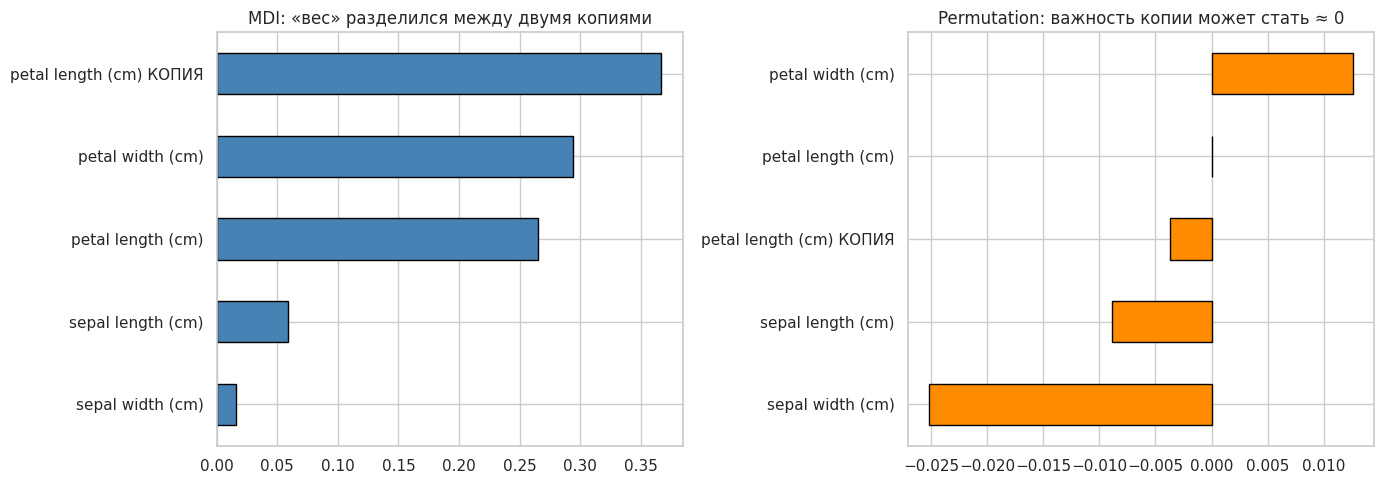

In [9]:
# Демонстрация: добавим к ирисам почти точную копию одного признака
X_corr = np.hstack([X, X[:, [2]] + np.random.normal(0, 0.01, size=(len(X), 1))])
feature_names_corr = feature_names + ['petal length (cm) КОПИЯ']

X_tr, X_te, y_tr, y_te = train_test_split(X_corr, y, test_size=0.3,
                                            random_state=42, stratify=y)
rf2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf2.fit(X_tr, y_tr)

mdi2 = pd.Series(rf2.feature_importances_, index=feature_names_corr).sort_values()
perm2 = permutation_importance(rf2, X_te, y_te, n_repeats=30, random_state=42)
perm2_series = pd.Series(perm2.importances_mean, index=feature_names_corr).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
mdi2.plot(kind='barh', color='steelblue', edgecolor='black', ax=axes[0])
axes[0].set_title('MDI: «вес» разделился между двумя копиями')
perm2_series.plot(kind='barh', color='darkorange', edgecolor='black', ax=axes[1])
axes[1].set_title('Permutation: важность копии может стать ≈ 0')
plt.tight_layout()
plt.show()

**Чему учит этот эксперимент.** После добавления почти точной копии признака `petal length` его MDI-важность **уменьшилась вдвое** — модель использует оба признака взаимозаменяемо. А permutation importance копии может оказаться **существенно ниже оригинала**, потому что при её удалении модель просто переключается на оригинал.

### Правила интерпретации важностей

1. **Не смешивайте MDI и Permutation в одном выводе** — у них разная семантика.
2. **Проверьте корреляции топ-признаков.** Если в топе оказались 3–4 коррелированных признака — их совокупный вклад больше, чем сумма индивидуальных важностей.
3. **Численная важность не пропорциональна физической значимости.** Признак с MDI = 0.30 не «в три раза важнее» признака с MDI = 0.10 — это лишь относительный рейтинг.
4. **«Важность» — это статистическое свойство модели на ваших данных**, а не физическое свойство признака. Другая модель на тех же данных даст другой рейтинг.
5. **Признак может иметь нулевую важность по двум разным причинам:** (а) он действительно бесполезен; (б) есть его коррелированный «дублёр». Различить можно через permutation на парах.

### Особенность LightGBM

LightGBM имеет **два** способа подсчёта важности через параметр `importance_type`:
- `importance_type='split'` — число использований признака для разбиения;
- `importance_type='gain'` — суммарный прирост качества при использовании признака (по умолчанию).

Документация: [LightGBM Booster.feature_importance](https://lightgbm.readthedocs.io/en/stable/pythonapi/lightgbm.Booster.html#lightgbm.Booster.feature_importance).

В вашем основном проекте на LightGBM возвращается `gain`-важность. Это аналог MDI и наследует все его особенности.

### Как применить к вашему проекту (задание 3)

Готовое решение не привожу. Наводящие вопросы:

1. **Какие признаки оказались в топе?** Имеют ли они физический смысл как индикаторы состояния? Если в топе оказался признак, который не должен влиять на отказы (например, что-то типа индекса записи, временная метка) — это сигнал о возможной утечке (target leakage).
2. **Есть ли в топе явно коррелированные признаки?** Например, если попали и `WEC: ava. Rotation`, и `WEC: max. Rotation` — это «дублёры», и их совокупный вклад больше суммы.
3. **Согласуются ли важности с тем, что вы видели в EDA?** Если каналы, которые на boxplot хорошо разделяли классы, попали в топ важности — это **подтверждение** валидности модели. Если же топ-1 признак вообще не выделялся на EDA — стоит разобраться, почему.
4. **Какие признаки специфичны для каждого класса?** Общая важность по модели не показывает, какой признак отвечает за `EF`, а какой за `AF`. Для этого нужен SHAP. Если хотите углубиться — [shap.readthedocs.io](https://shap.readthedocs.io/).
5. **Стоит ли посчитать ещё и permutation importance?** Если ответы двух методов сильно разойдутся — это материал для отдельного обсуждения в выводах.


## 4. Валидация моделей на временных рядах

**Соответствует заданию 4.** В основном проекте применялась `StratifiedKFold` — случайное разбиение со стратификацией. Вам нужно заменить её на `TimeSeriesSplit` и объяснить, почему результат может измениться. Этот раздел даёт теорию.

### Проблема случайного разбиения временных рядов

Стандартный `train_test_split` и `KFold` предполагают, что объекты в выборке **независимы и одинаково распределены** (i.i.d.). Для временных рядов это **не выполнено**:

1. Соседние во времени наблюдения **похожи** друг на друга (физические процессы инерционны).
2. Распределение признаков **меняется со временем** (сезонность, износ оборудования, изменения режима эксплуатации).
3. В реальном применении модель **никогда** не имеет доступа к будущим данным при предсказании прошлого.

Если случайно разбить временной ряд на train/test, в train окажутся объекты, **очень близкие по времени** к объектам test. Модель «угадывает» test не за счёт обобщения, а за счёт того, что почти такие же объекты были рядом во времени. Это **утечка из будущего в прошлое** (look-ahead bias).

### TimeSeriesSplit: правильная схема валидации

[`sklearn.model_selection.TimeSeriesSplit`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html) реализует **последовательное расширяющееся** разбиение:

- Фолд 1: train = первые $n_1$ наблюдений, test = следующие $m$;
- Фолд 2: train = первые $n_2 > n_1$ наблюдений, test = следующие $m$;
- ...

Каждый train предшествует своему test по времени. Это имитирует реальную эксплуатацию модели: вы обучаете её на прошлом, а применяете в будущем.

Подробнее о методологии валидации временных рядов: [Bergmeir & Benítez, *On the use of cross-validation for time series predictor evaluation*, Information Sciences 2012](https://www.sciencedirect.com/science/article/abs/pii/S0020025511006773).


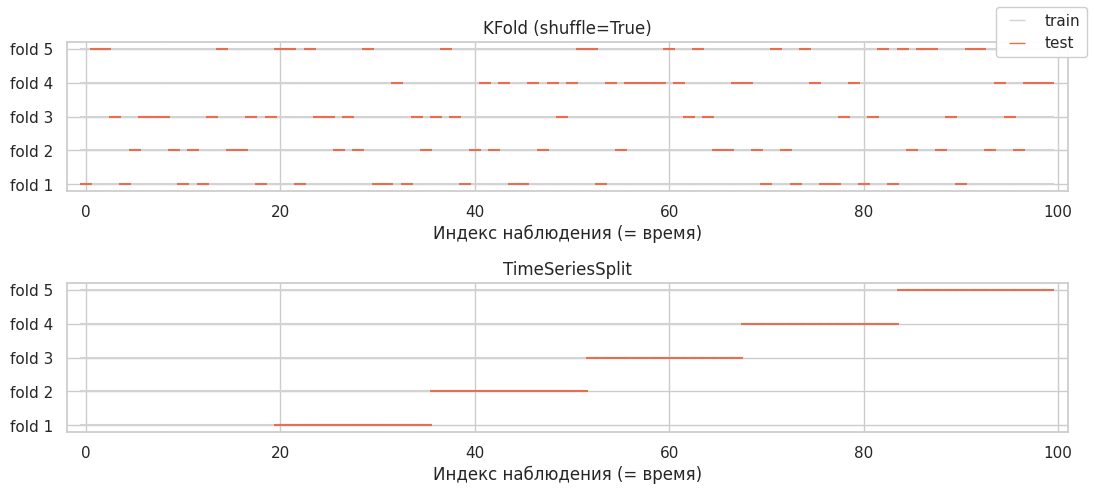

In [10]:
# Визуализация: чем отличается KFold от TimeSeriesSplit
from sklearn.model_selection import KFold, TimeSeriesSplit

n_samples = 100
n_splits = 5

fig, axes = plt.subplots(2, 1, figsize=(11, 5))

for ax, splitter, name in [
    (axes[0], KFold(n_splits=n_splits, shuffle=True, random_state=42), 'KFold (shuffle=True)'),
    (axes[1], TimeSeriesSplit(n_splits=n_splits),                      'TimeSeriesSplit'),
]:
    for fold_idx, (train_idx, test_idx) in enumerate(splitter.split(np.arange(n_samples))):
        # train — серым, test — оранжевым
        ax.scatter(train_idx, np.full_like(train_idx, fold_idx),
                    c='lightgray', marker='_', s=80)
        ax.scatter(test_idx, np.full_like(test_idx, fold_idx),
                    c='#e76f51', marker='_', s=80)
    ax.set_yticks(range(n_splits))
    ax.set_yticklabels([f'fold {i+1}' for i in range(n_splits)])
    ax.set_xlabel('Индекс наблюдения (= время)')
    ax.set_title(name)
    ax.set_xlim(-2, n_samples + 1)

# Легенда
from matplotlib.lines import Line2D
handles = [Line2D([0], [0], color='lightgray', marker='_', lw=0, markersize=12, label='train'),
            Line2D([0], [0], color='#e76f51',  marker='_', lw=0, markersize=12, label='test')]
fig.legend(handles=handles, loc='upper right', framealpha=0.95)

plt.tight_layout()
plt.show()

### Чтение графика

- В **KFold** обучающие наблюдения «перемешаны» среди тестовых — модель в одном фолде учится на объектах, лежащих по обе стороны от каждого тестового. Это похоже на интерполяцию, и качество может быть искусственно завышено.
- В **TimeSeriesSplit** train всегда **левее** test. Каждый следующий фолд использует больше данных. Тестовая выборка фиксированного размера.

### Дополнительные параметры TimeSeriesSplit

`TimeSeriesSplit` принимает несколько важных параметров:

| Параметр | Назначение |
|---|---|
| `n_splits` | Число фолдов |
| `max_train_size` | Ограничение размера train (sliding window вместо expanding) |
| `test_size` | Фиксированный размер test |
| `gap` | Зазор между train и test — учитывает временную задержку обновления данных |

Параметр `gap` особенно важен для предиктивной аналитики. Если модель должна предсказать отказ **за час до его возникновения**, то test нельзя строить впритык к train — между ними должен быть «слепой» промежуток размером с горизонт прогноза.


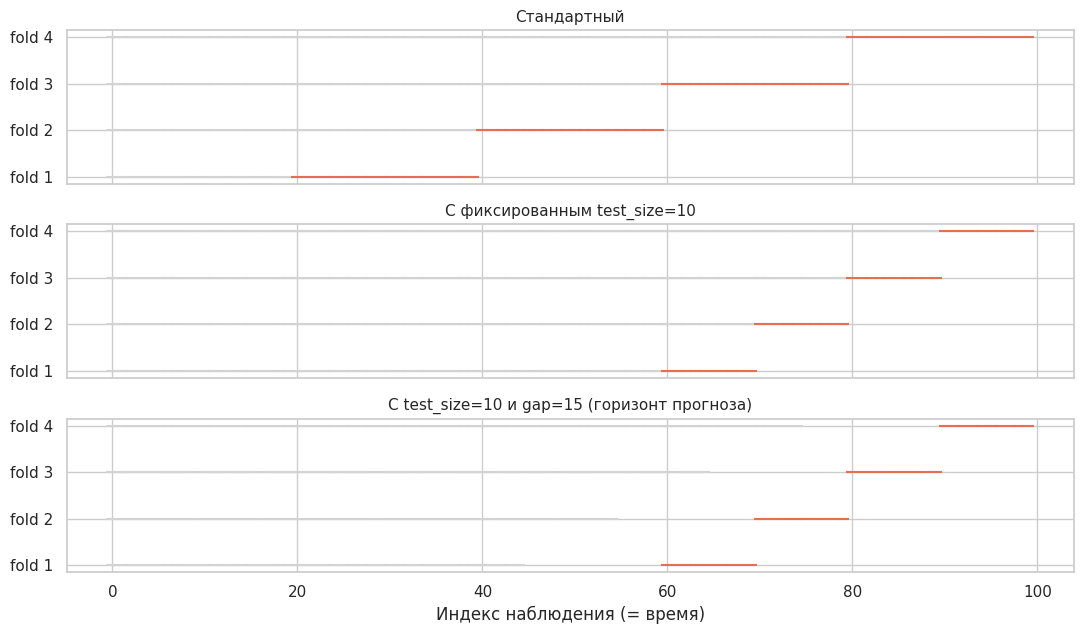

In [11]:
# Сравнение трёх вариантов TimeSeriesSplit
fig, axes = plt.subplots(3, 1, figsize=(11, 6.5), sharex=True)

variants = [
    ('Стандартный',
     TimeSeriesSplit(n_splits=4)),
    ('С фиксированным test_size=10',
     TimeSeriesSplit(n_splits=4, test_size=10)),
    ('С test_size=10 и gap=15 (горизонт прогноза)',
     TimeSeriesSplit(n_splits=4, test_size=10, gap=15)),
]

for ax, (name, splitter) in zip(axes, variants):
    for fold_idx, (train_idx, test_idx) in enumerate(splitter.split(np.arange(n_samples))):
        ax.scatter(train_idx, np.full_like(train_idx, fold_idx),
                    c='lightgray', marker='_', s=80)
        ax.scatter(test_idx, np.full_like(test_idx, fold_idx),
                    c='#e76f51', marker='_', s=80)
    ax.set_yticks(range(4))
    ax.set_yticklabels([f'fold {i+1}' for i in range(4)])
    ax.set_title(name, fontsize=11)

axes[-1].set_xlabel('Индекс наблюдения (= время)')
plt.tight_layout()
plt.show()

### Стратификация и TimeSeriesSplit

Заметная сложность: `TimeSeriesSplit` **не стратифицирован**. В фолдах могут оказаться периоды без представителей миноритарных классов — особенно если отказы концентрируются в одном промежутке времени.

Это **реальная проблема** вашего датасета: события типа `EF` сосредоточены в октябре–ноябре 2014. При TimeSeriesSplit все события `EF` могут оказаться в одном фолде test и **полностью отсутствовать** в train. Метрики для этого фолда будут провальными — и это **физически корректное** отражение того, что произойдёт в реальности, если модель столкнётся с новым типом отказа.

Решения:
1. **Объединить близкие классы** перед TimeSeriesSplit;
2. **Использовать `GroupKFold` с временными группами** (квартал, месяц), где стратификация делается по типу отказа;
3. **Принять провал** на некоторых фолдах как индикатор реальных ограничений модели.

См. также: [`TimeSeriesSplit` user guide](https://scikit-learn.org/stable/modules/cross_validation.html#time-series-split) и обзор [Cross-Validation strategies in scikit-learn](https://scikit-learn.org/stable/modules/cross_validation.html).

### Демонстрация: «оптимистичная» оценка случайным KFold


In [12]:
# Создадим синтетический временной ряд с trend и шумом
n = 300
t = np.arange(n)
np.random.seed(42)
# Признак: тренд + сезон + шум
X_ts = np.column_stack([
    t / n + np.random.normal(0, 0.1, n),
    np.sin(2 * np.pi * t / 50) + np.random.normal(0, 0.2, n),
])
# Цель: зависит от текущего и сдвинутого по времени значений
y_ts = ((X_ts[:, 0] + 0.5 * X_ts[:, 1]) > 0.5).astype(int)

# Сравним оценку accuracy при двух стратегиях
scores_kf = cross_val_score(
    RandomForestClassifier(n_estimators=50, random_state=42),
    X_ts, y_ts,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy'
)
scores_ts = cross_val_score(
    RandomForestClassifier(n_estimators=50, random_state=42),
    X_ts, y_ts,
    cv=TimeSeriesSplit(n_splits=5),
    scoring='accuracy'
)

print('KFold (shuffle=True):')
print(f'   фолды: {np.round(scores_kf, 3)}, среднее = {scores_kf.mean():.3f}')
print('\nTimeSeriesSplit:')
print(f'   фолды: {np.round(scores_ts, 3)}, среднее = {scores_ts.mean():.3f}')
print(f'\nРазница в средней accuracy: {scores_kf.mean() - scores_ts.mean():+.3f}')

KFold (shuffle=True):
   фолды: [0.95  0.967 1.    0.95  0.983], среднее = 0.970

TimeSeriesSplit:
   фолды: [0.84 0.9  0.88 0.78 0.82], среднее = 0.844

Разница в средней accuracy: +0.126


**Что увидите.** На временном ряде с трендом случайный KFold обычно даёт **более высокую** оценку, чем TimeSeriesSplit. Это и есть упомянутая выше «оптимистичная» оценка: случайное разбиение позволяет модели «подсматривать» из будущего в прошлое и обратно.

В вашем основном проекте ровно та же ситуация: метрики при `StratifiedKFold` ≈ 0.85, а при `TimeSeriesSplit` **скорее всего будут ниже**. Это **не недостаток модели** — это **более честная** оценка.

### Как применить к вашему проекту (задание 4)

Решение не привожу. Подумайте над следующими аспектами:

1. **Какой `n_splits` выбрать?** Стандартно 5–10. Учтите, что при TimeSeriesSplit первый train очень маленький — возможно, имеет смысл задать `max_train_size`, чтобы все фолды учили на одинаковом количестве данных.
2. **Нужен ли `gap`?** Зависит от того, **за сколько до отказа** вы хотите его предсказывать. Если за 10 минут — gap=1 (одна запись = 10 мин). Если хотите 1 час — gap=6. Без gap модель «видит» отказ практически в тот же момент, что не сильно полезно.
3. **Что делать с миноритарными классами?** Если в одном из тестовых фолдов нет представителей класса `MF`, метрики для него будут `NaN` или 0. Обсудите это в отчёте — это **методологически значимое наблюдение**, а не ошибка.
4. **Какое падение метрики ожидать?** Если разница StratifiedKFold vs TimeSeriesSplit > 0.10 п. п. F1 — это сильный сигнал, что временная структура данных существенна. Если < 0.03 — данные практически i.i.d., и случайное разбиение допустимо.
5. **Что включить в отчёт?** Помимо численных метрик — **философское обсуждение**: какая из оценок «правильная»? Какую модель вы стали бы применять в продакшене и почему?


## 5. Снижение размерности и визуализация

**Соответствует заданию 5.** В основном проекте вам нужно построить PCA-проекцию признаков SCADA в 2D и оценить визуальную разделимость классов. Этот раздел даёт теорию PCA и его альтернатив.

### Зачем снижать размерность

В вашем датасете ≈50 признаков. Их **невозможно визуализировать** напрямую. Можно построить пары graph (pairplot), но это $C_{50}^2 = 1225$ графиков — нечитаемо. Альтернатива — спроецировать высокоразмерное пространство на 2D или 3D, сохранив **максимум структуры**.

Применений несколько:
1. **Визуализация**: посмотреть, образуют ли классы компактные кластеры;
2. **Препроцессинг для модели**: уменьшить число признаков, сохранив информацию;
3. **Шумоподавление**: убрать малозначимые направления;
4. **Декорреляция признаков**: получить ортогональный базис.

### PCA: метод главных компонент

**Principal Component Analysis** — линейное преобразование, которое находит ортогональные направления в данных, упорядоченные по убыванию дисперсии:

1. Центрировать данные: $X - \bar{X}$;
2. Найти собственные векторы $v_1, v_2, \ldots$ ковариационной матрицы $\mathrm{Cov}(X)$, упорядоченные по убыванию собственных значений $\lambda_1 \geq \lambda_2 \geq \ldots$;
3. Спроецировать данные на первые $k$ векторов: $X_{red} = X \cdot V_k$.

**Главное свойство.** Первая компонента — направление **максимальной дисперсии** данных. Вторая — направление максимальной дисперсии, **ортогональное первой**. И так далее.

Реализация: [`sklearn.decomposition.PCA`](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html).

**Принципиально важно: PCA требует стандартизации признаков** (StandardScaler), иначе признаки с большими абсолютными значениями (например, температуры по сравнению с углами) будут доминировать.

### Демонстрация на ирисах


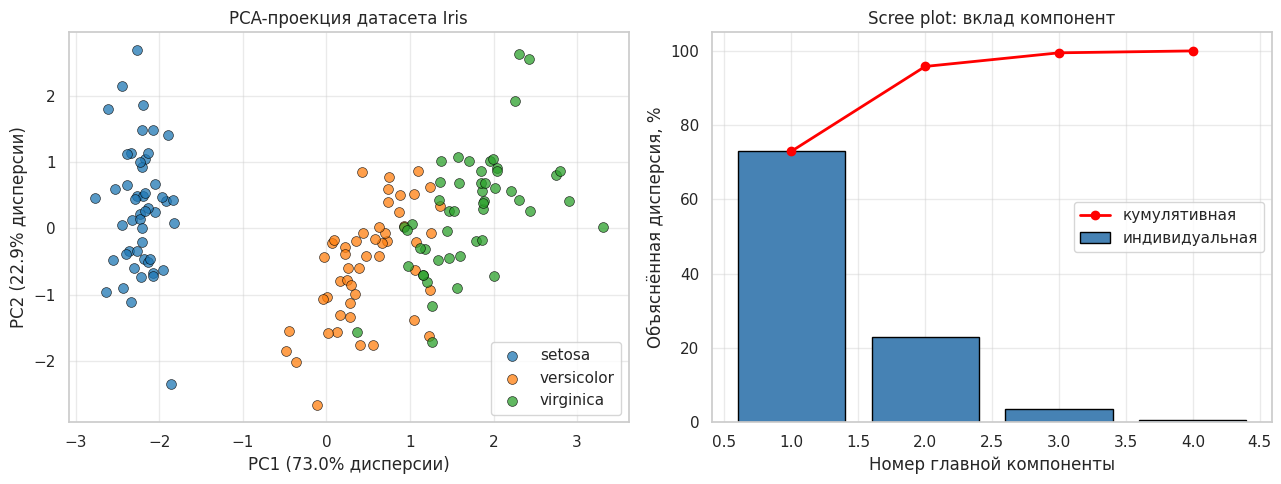

Первые 2 компоненты объясняют: 95.8% общей дисперсии


In [13]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Используем ирисы; гарантируем, что X — numpy-массив
X = iris.data.values
y = iris.target.values

# Шаг 1: стандартизация
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Шаг 2: PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Шаг 3: scatter с разметкой по классам
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Левый: scatter
colors_iris = ['#1f77b4', '#ff7f0e', '#2ca02c']
for i, name in enumerate(iris.target_names):
    mask = y == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                     color=colors_iris[i], label=name,
                     s=50, alpha=0.75, edgecolor='black', linewidth=0.5)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% дисперсии)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% дисперсии)')
axes[0].set_title('PCA-проекция датасета Iris')
axes[0].legend()
axes[0].grid(True, alpha=0.4)

# Правый: scree plot — доля объяснённой дисперсии
pca_full = PCA().fit(X_scaled)
explained = pca_full.explained_variance_ratio_
cum_explained = explained.cumsum()
axes[1].bar(range(1, len(explained)+1), explained * 100,
             color='steelblue', edgecolor='black', label='индивидуальная')
axes[1].plot(range(1, len(explained)+1), cum_explained * 100,
              color='red', marker='o', linewidth=2, label='кумулятивная')
axes[1].set_xlabel('Номер главной компоненты')
axes[1].set_ylabel('Объяснённая дисперсия, %')
axes[1].set_title('Scree plot: вклад компонент')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

print(f'Первые 2 компоненты объясняют: {cum_explained[1]*100:.1f}% общей дисперсии')

### Чтение PCA-проекции

1. **Доля объяснённой дисперсии** — насколько хорошо 2D-проекция передаёт исходные данные. Если первые 2 компоненты объясняют > 70 %, проекция надёжна. Если < 40 % — структура искажена, доверять визуальной разделимости нельзя.
2. **Scree plot** показывает, сколько компонент достаточно. «Локоть» (резкий перегиб) — естественная точка отсечения.
3. **Кластеры на 2D-проекции** — индикатор разделимости, но не доказательство. Классы могут быть разделимы в высокоразмерном пространстве и слиты в 2D (когда разделяющая поверхность ортогональна плоскости проекции). Обратное тоже верно — кажущееся слияние в 2D **не значит**, что классы неразделимы.

### Что делать, если PCA не показывает разделимости

PCA — **линейный** метод. Если классы разделимы нелинейно (например, лежат на пересекающихся спиралях), PCA не покажет структуру. Тогда применяют **нелинейные методы снижения размерности**.

| Метод | Принцип | Когда выбирать |
|---|---|---|
| **PCA** | Линейная проекция, максимизация дисперсии | Базовый шаг, всегда стоит начать с него |
| **t-SNE** | Сохранение **локальных** соседств | Визуализация кластеров, при $n < 10\,000$ |
| **UMAP** | Сохранение локальной и глобальной структуры | То же, что t-SNE, но быстрее и стабильнее |
| **Kernel PCA** | PCA в нелинейном пространстве (через kernel) | Известно, что данные нелинейны (RBF, polynomial) |

Первоисточник t-SNE: [van der Maaten & Hinton, *Visualizing Data using t-SNE*, JMLR 2008](https://www.jmlr.org/papers/v9/vandermaaten08a.html).
Первоисточник UMAP: [McInnes, Healy, Melville, *UMAP*, arXiv 2018](https://arxiv.org/abs/1802.03426).

### Сравнение PCA, t-SNE и UMAP на одном датасете


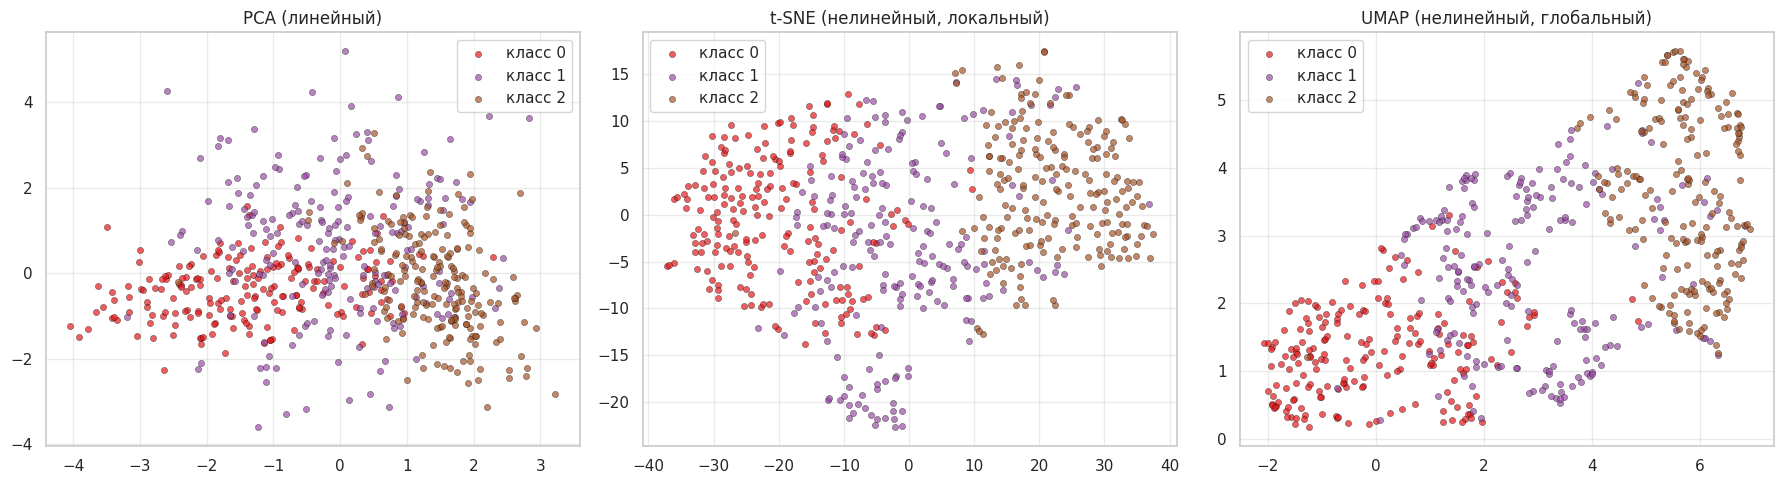

In [14]:
from sklearn.manifold import TSNE

# Сделаем датасет посложнее: 3 класса в 10-мерном пространстве с шумом
X_demo, y_demo = make_classification(
    n_samples=600, n_features=10, n_informative=4, n_redundant=2,
    n_classes=3, n_clusters_per_class=1, class_sep=1.2, random_state=42
)
X_demo_scaled = StandardScaler().fit_transform(X_demo)

# PCA
X_pca = PCA(n_components=2, random_state=42).fit_transform(X_demo_scaled)

# t-SNE
X_tsne = TSNE(n_components=2, perplexity=30,
                random_state=42, init='pca').fit_transform(X_demo_scaled)

# UMAP (если установлен)
try:
    import umap
    X_umap = umap.UMAP(n_components=2, n_neighbors=15,
                       min_dist=0.1, random_state=42).fit_transform(X_demo_scaled)
    has_umap = True
except ImportError:
    has_umap = False

n_plots = 3 if has_umap else 2
fig, axes = plt.subplots(1, n_plots, figsize=(6*n_plots, 5))

projections = [(X_pca, 'PCA (линейный)'), (X_tsne, 't-SNE (нелинейный, локальный)')]
if has_umap:
    projections.append((X_umap, 'UMAP (нелинейный, глобальный)'))

cmap = plt.cm.Set1
for ax, (X_proj, name) in zip(axes, projections):
    for cls in np.unique(y_demo):
        mask = y_demo == cls
        ax.scatter(X_proj[mask, 0], X_proj[mask, 1],
                    color=cmap(cls / 3), label=f'класс {cls}',
                    s=20, alpha=0.7, edgecolor='black', linewidth=0.3)
    ax.set_title(name)
    ax.legend()
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

### Ключевые предостережения

1. **t-SNE и UMAP искажают расстояния.** Расстояние между точками на 2D-проекции **не соответствует** расстоянию в исходном пространстве. Размер и положение кластеров на t-SNE — артефакты, нельзя интерпретировать как меру «удалённости» классов.
2. **PCA сохраняет расстояния** в первых $k$ компонентах. Расстояние между точками на PCA — это нижняя оценка истинного расстояния.
3. **t-SNE/UMAP имеют гиперпараметры**, сильно влияющие на результат:
   - `perplexity` для t-SNE (5–50; маленькое — локальная структура, большое — глобальная);
   - `n_neighbors` и `min_dist` для UMAP.
   Полезный обзор: [How to Use t-SNE Effectively](https://distill.pub/2016/misread-tsne/).
4. **Для воспроизводимости** всегда фиксируйте `random_state`. t-SNE без фиксации даст разные проекции при разных запусках.
5. **Стандартизация обязательна** для PCA. Для t-SNE и UMAP — желательна.

### Что делать с результатом

После проекции и визуализации возможные сценарии:

| Что вы видите | Что это значит |
|---|---|
| Классы образуют чёткие кластеры в 2D | Задача легко решается, можно начать с простой модели |
| Классы перемешаны полностью | Признаки недостаточны или нужна нелинейная модель |
| Несколько классов сливаются, остальные разделены | Подгруппы классов физически близки (как ваши `EF` и `FF`) |
| Один класс размазан, остальные компактны | Размазанный класс гетерогенен (несколько «подтипов») |

### Как применить к вашему проекту (задание 5)

Решение не привожу. Наводящие вопросы:

1. **Какие признаки взять для PCA?** Имеет ли смысл включать только те ≈50 признаков, что используются моделью, или все исходные SCADA-каналы? Помните: leakage-признаки (мощность, выработка) дадут «искусственно красивую» картинку, на которой класс `GF` отделится за счёт нулевой мощности — но это не интересно с точки зрения предиктивности.
2. **Сколько компонент удерживать?** Постройте scree plot. Если первые 2 объясняют, скажем, 35 % — это много или мало? Для научной интерпретации — мало; для визуализации — нормально.
3. **Какие пары компонент смотреть?** PC1-PC2 — стандарт, но может оказаться, что класс `MF` отделяется только в PC3-PC4. Постройте несколько пар.
4. **Помогает ли подвыборка мажоритарного класса?** Если рисовать 30 000 точек `NF` поверх 50 точек `MF`, миноритарный класс не виден. Подвыборка `NF` до сопоставимого размера (или использование `alpha=0.05` для `NF`) сильно улучшит читаемость.
5. **Что вы напишете в выводе?** Полное содержательное наблюдение должно включать (а) что разделимо, (б) что слито, (в) какой класс гетерогенен (если есть), (г) согласуется ли картина с тем, что показала модель.
6. **Стоит ли попробовать t-SNE/UMAP?** Если PCA не показывает разделимости — нелинейный метод может выявить структуру. Это **бонусная** часть задания.


## Контрольный список перед сдачей заданий

Перед тем как сдать решение по каждому заданию, проверьте:

### Общие принципы (для всех заданий)

- [ ] Код **запускается без ошибок** в чистой среде Colab (проверить с `Restart Runtime` → `Run all`).
- [ ] Все графики **подписаны** (заголовок, оси, легенда, единицы измерения, размер выборки если уместно).
- [ ] Каждый график сопровождается **текстовой интерпретацией** (1–3 предложения о том, что вы видите).
- [ ] Численные результаты приведены с **разумной точностью** (3–4 значащие цифры, не 10).
- [ ] В выводах указаны **ограничения** вашего подхода и метода.

### По заданию 1 (boxplot)
- [ ] Правильно ли отображены все классы, включая редкие?
- [ ] Сформулирована ли физическая гипотеза до построения графика?
- [ ] Описано ли, **что именно** характерно для класса `EF` (медиана? разброс? выбросы?)

### По заданию 2 (BorderlineSMOTE)
- [ ] BorderlineSMOTE находится **внутри pipeline**, не применяется заранее?
- [ ] Сравнение проводится по **per-class** метрикам, а не только по macro?
- [ ] Есть обсуждение, **почему** результат улучшился или ухудшился именно так?

### По заданию 3 (feature importance)
- [ ] Использован атрибут именно тюнингованной (после Grid Search) модели?
- [ ] Топ-признаки имеют **физический смысл**?
- [ ] Проверена ли корреляция между топ-признаками?
- [ ] Нет ли в топе случайно оставленных leakage-признаков?

### По заданию 4 (TimeSeriesSplit)
- [ ] Использован параметр `gap` (или объяснено, почему не использован)?
- [ ] Описано, как изменились метрики **по классам**, а не только в среднем?
- [ ] Объяснено, **почему** TimeSeriesSplit даёт другую (обычно меньшую) оценку?

### По заданию 5 (PCA-проекция)
- [ ] Применена стандартизация перед PCA?
- [ ] Указана доля объяснённой дисперсии первых компонент?
- [ ] Описана визуальная разделимость **по каждому классу**?
- [ ] Графики читаемы (мажоритарный класс не «забивает» миноритарные)?

## Дополнительные источники

### По теории
- Géron, A. *Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow*. 3rd ed., O'Reilly, 2022. — комплексное практическое руководство.
- Hastie, T., Tibshirani, R., Friedman, J. *The Elements of Statistical Learning*. Springer. — теоретический фундамент. [Бесплатный PDF](https://hastie.su.domains/ElemStatLearn/).
- Molnar, C. *Interpretable Machine Learning*. — современный учебник по интерпретации моделей. [Онлайн](https://christophm.github.io/interpretable-ml-book/).

### По методам
- Boxplot и EDA: [Tukey J. W., *Exploratory Data Analysis*, Addison-Wesley, 1977](https://archive.org/details/exploratorydataa00tuke_0).
- SMOTE и imbalanced learning: [imbalanced-learn user guide](https://imbalanced-learn.org/stable/user_guide.html).
- Feature importance: [Permutation Importance vs MDI in scikit-learn](https://scikit-learn.org/stable/auto_examples/inspection/plot_permutation_importance.html).
- Кросс-валидация: [scikit-learn user guide on cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html).
- t-SNE pitfalls: [How to Use t-SNE Effectively, Distill](https://distill.pub/2016/misread-tsne/).
- PCA visualisation tutorials: [PCA in scikit-learn examples](https://scikit-learn.org/stable/auto_examples/decomposition/plot_pca_iris.html).

### Прикладные обзоры по ВЭУ
- Tautz-Weinert, J., Watson, S. J. *Using SCADA data for wind turbine condition monitoring — a review.* IET Renewable Power Generation, 2017. [DOI](https://doi.org/10.1049/iet-rpg.2016.0248)
- Stetco, A. et al. *Machine learning methods for wind turbine condition monitoring: A review.* Renewable Energy, 2019. [DOI](https://doi.org/10.1016/j.renene.2018.10.047)

Успешной работы.
